# Embedding Neighborhood Change: Evaluating Geospatial Foundation Models for Urban Decline and Reinvestment Detection in Detroit
### Prepared for MUSA 6500 Spring 2026 (Deep Learning in Remote Sensing)
#### Authors: Joey Cahill, Sujan Kakumanu, Angel Rutherford

In [17]:
# Setup Code Block

# initialize api key to access Alpha Earth
import os
os.environ["GOOGLE_MAPS_API_KEY"] = "YOUR_API_KEY"

# imports

import geopandas as gpd
import ee
import json
import geemap
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Load study area from geopackage
NOTEBOOK_DIR = Path().resolve()

grid_path = NOTEBOOK_DIR / 'final_project_files' / 'data' / 'detroit_tile_grid.gpkg'

grid_gdf = gpd.read_file(grid_path)

## Problem Definition & Technical Justification

Begin by restating the problem you're solving, your target user, and the specific output your solution produces. Then, refined from your proposal, explain the logical chain from problem to method: what your model is actually learning, why your chosen approach is appropriate for the task, and what failure modes you anticipated. Now that you've implemented your solution, discuss whether you observed any of these failure modes in practice and how you addressed them.


### Problem Definition

Cities in economically distressed regions face significant challenges in monitoring neighborhood change at scale. Detroit provides a clear example. In 2014, the city partnered with multiple organizations to conduct a comprehensive parcel-level survey of nearly 380,000 properties, relying heavily on crowdsourced photo collection to produce a detailed snapshot of property conditions. While effective, this process required substantial time, labor, and financial resources, and its reliance on periodic resurveying limits its ability to track ongoing neighborhood change in a timely manner.

This project proposes a scalable, repeatable approach to neighborhood change detection using precomputed satellite image embeddings. Rather than replacing detailed parcel-level surveys, the goal is to evaluate whether existing geospatial foundation models can consistently identify areas of meaningful physical change across the city, enabling more efficient targeting of limited public resources without the cost of traditional survey methods.

The primary users of this project are City of Detroit and Detroit Land Bank Authority (DLBA) officials responsible for prioritizing property inspections, allocating reinvestment resources, and determining appropriate interventions across neighborhoods experiencing varying degrees of stability, decline, and recovery.

### Technical Justification


## Methodological Precedent

Summarize the three or more sources that informed your approach and explain how they shaped your design decisions. Update this section if your reading evolved during implementation.



## Data & Preprocessing

Describe your dataset(s), including source, spatial and temporal extent, resolution, and bands or features used. Discuss any data quality issues you encountered and how you addressed them. Explain your preprocessing steps and feature engineering choices, with justification for each decision.


### Alpha Earth

Source & Extent
The AlphaEarth component uses the Google Satellite Embedding dataset (GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL), accessed via the Google Earth Engine data catalog. We use the 2018 and 2022 annual layers clipped to the project study area boundary

Resolution and Features
Each pixel contains a 64-dimensional unit-length embedding vector representing an annual aggregate across Sentinel-2, Sentinel-1 SAR, and Landsat thermal imaging. Unlike the raw imagery used in our baseline model, these encodings summarize all sensor inputs simultaneously into a single learned representation.

Data Quality
Since the embeddings are aggregates of a full years sensor data, they are resistant to factors like cloud cover which would need to be pre-processed out of raw sensor data. No additional filtering was necessary for these embeddings.

Preprocessing
When filtering by study area bounds and calling mosaic() to combine tiles, Earth Engine strips the native UTM projection metadata and defaults to WGS84. Before performing any spatial operations, it was necessary to restore the projection and specify the native 10 meter pixel scale. This was the only preprocessing step required contrasting preprocessing for the baseline model, which required cloud masking, band selection, and index computation before analysis could begin.



## Modeling Approach

Present your baseline model first—the simple, non-deep-learning approach you used to establish a performance floor. Report its results before describing your primary model. For your primary model, explain the architecture, training process, and any hyperparameter tuning you performed. Compare your primary model to the baseline: how much did the added complexity improve performance, and was that improvement worth the cost?


### Baseline Model
Baseline model: we use the same grid that Clay uses, and that Alpha Earth aggregates to. For each grid cell, we can assign a series of values. The values come from domain knowledge (Detroit open data sources) and a research article talking about using that + NDVI and impervious surfaces. So essentially, each grid cell will have a vector.

K-means (k=3) can be run on this grid of cells.

### Clay
Clay takes an input of a grid of A x A tiles. The output is then embeddings calculated for each of those tiles (1024 size vector embedding). K-means is calculated on the results. We use NAIP imagery. 

### AlphaEarth Embeddings
AlphaEarth already has embeddings pre-caluclated, but they exist at the pixel level with 10m each pixel. 

To compare these results to that of Clay, we can aggregate the AlphaEarth results to the Clay A x A tiles. Run k-means on this.
AND/OR
We can just run k-means on the output as is.

In [18]:
# authentication and project selection from google cloud

ee.Authenticate()
ee.Initialize(project='deep-learning-detroit')

In [19]:
# Convert study area to EE geometry
# Reproject to WGS84 if needed (EE requires 4326)
grid_gdf_wgs84 = grid_gdf.to_crs('EPSG:4326')[['geometry']]
geojson_dict = json.loads(grid_gdf_wgs84.to_json())

# If single feature
if len(geojson_dict['features']) == 1:
    study_area_ee = ee.Geometry(geojson_dict['features'][0]['geometry'])
else:
    # Dissolve multiple features into one geometry
    geometries = [ee.Geometry(f['geometry']) for f in geojson_dict['features']]
    study_area_ee = ee.Geometry.MultiPolygon(
        [g for g in geometries]
    ).dissolve()

print('Study area geometry loaded successfully')

Study area geometry loaded successfully


In [20]:
# Fetch AlphaEarth embeddings for study area
dataset = ee.ImageCollection("GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL")

emb_2018 = dataset.filterDate("2018-01-01", "2019-01-01").filterBounds(study_area_ee).mosaic()
emb_2022 = dataset.filterDate("2022-01-01", "2023-01-01").filterBounds(study_area_ee).mosaic()

print('Embeddings fetched for 2018 and 2022')

Embeddings fetched for 2018 and 2022


In [21]:
# Compute change magnitude between 2018 and 2022
diff = emb_2022.subtract(emb_2018)
change_magnitude = diff.pow(2).reduce(ee.Reducer.sum()).sqrt().clip(study_area_ee)

In [22]:
# Sample change magnitude for summary statistics
sample = change_magnitude.rename('change').sample(
    region=study_area_ee,
    scale=30,
    numPixels=5000,
    seed=42,
    geometries=True
)

df = geemap.ee_to_df(sample)
print(df.head())
print(df.shape)

     change
0  0.300450
1  0.360625
2  0.356914
3  0.241721
4  0.299631
(5013, 1)


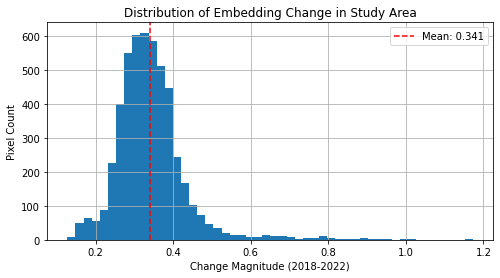

Mean change: 0.3411
Max change:  1.1737
Top 10% threshold: 0.4264


In [23]:
# Distribution of change values
df['change'].hist(bins=50, figsize=(8, 4))
plt.xlabel('Change Magnitude (2018-2022)')
plt.ylabel('Pixel Count')
plt.title('Distribution of Embedding Change in Study Area')
plt.axvline(df['change'].mean(), color='red', linestyle='--', label=f'Mean: {df["change"].mean():.3f}')
plt.legend()
plt.show()

print(f"Mean change: {df['change'].mean():.4f}")
print(f"Max change:  {df['change'].max():.4f}")
print(f"Top 10% threshold: {df['change'].quantile(0.9):.4f}")

In [24]:
# Map of change magnitude over study area
change_map = geemap.Map(basemap="SATELLITE")
change_map.centerObject(study_area_ee, zoom=13)

change_vis = {
    'min': 0,
    'max': 0.5,
    'palette': ['#2166ac', '#f7f7f7', '#d6604d', '#b2182b']
}
change_map.addLayer(change_magnitude, change_vis, 'Embedding Change 2018-2022')

study_area_fc = ee.FeatureCollection([ee.Feature(study_area_ee)])
change_map.addLayer(study_area_fc, {}, 'Study Area Boundary')

change_map.add_colorbar(change_vis, label='Change Magnitude')
change_map

RuntimeError: Error creating a Maps API session:
{'error': {'code': 400, 'message': 'API key not valid. Please pass a valid API key.', 'errors': [{'message': 'API key not valid. Please pass a valid API key.', 'domain': 'global', 'reason': 'badRequest'}], 'status': 'INVALID_ARGUMENT', 'details': [{'@type': 'type.googleapis.com/google.rpc.ErrorInfo', 'reason': 'API_KEY_INVALID', 'domain': 'googleapis.com', 'metadata': {'service': 'tile.googleapis.com'}}, {'@type': 'type.googleapis.com/google.rpc.LocalizedMessage', 'locale': 'en-US', 'message': 'API key not valid. Please pass a valid API key.'}]}}.

In [ ]:
# Cluster on full 2022 embeddings (64 dims)
training_emb = emb_2022.sample(
    region=study_area_ee,
    scale=10,
    numPixels=5000,
    seed=42
)

clusterer_emb = ee.Clusterer.wekaKMeans(5).train(training_emb)
clustered_2018 = emb_2018.cluster(clusterer_emb).clip(study_area_ee)
clustered_2022 = emb_2022.cluster(clusterer_emb).clip(study_area_ee)

# cluster change between years
cluster_change = clustered_2022.subtract(clustered_2018).neq(0).clip(study_area_ee)

In [ ]:
# map of kmeans clusters on full embeddings

cluster_vis_emb = {
    'min': 0,
    'max': 4,
    'palette': ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
}

change_vis_binary = {
    'min': 0,
    'max': 1,
    'palette': ['white', 'red']
}

k_means_map = geemap.Map()
k_means_map.centerObject(study_area_ee, zoom=13)
k_means_map.add_basemap("SATELLITE")

k_means_map.addLayer(clustered_2018, cluster_vis_emb, 'Clusters 2018')
k_means_map.addLayer(clustered_2022, cluster_vis_emb, 'Clusters 2022')
k_means_map.addLayer(cluster_change, change_vis_binary, 'Pixels That Changed Cluster')

study_area_fc = ee.FeatureCollection([ee.Feature(study_area_ee)])
k_means_map.addLayer(study_area_fc, {}, 'Study Area Boundary')

k_means_map.add_colorbar(cluster_vis_emb, label='Cluster (0-4)')
k_means_map

Map(center=[42.35836452427712, -83.06660430997441], controls=(WidgetControl(options=['position', 'transparent_…

## Evaluation & Analysis

Report your evaluation metrics with appropriate context. Beyond the numbers, discuss what your model gets right and wrong. Include example predictions that illustrate both successes and failures—visual examples are particularly valuable here. Be honest about limitations: constraints from labeled data availability, computational resources, or generalizability to other regions or time periods.


### Notes on evaluation: 


## Future Work

Describe what you would do with more time or resources. How could this solution be scaled, improved, or operationalized for real-world use?